<>:184: SyntaxWarning: invalid escape sequence '\m'
<>:184: SyntaxWarning: invalid escape sequence '\m'
<>:184: SyntaxWarning: invalid escape sequence '\s'
<>:184: SyntaxWarning: invalid escape sequence '\m'
<>:184: SyntaxWarning: invalid escape sequence '\m'
<>:184: SyntaxWarning: invalid escape sequence '\s'
C:\Users\AlbireoBai\AppData\Local\Temp\ipykernel_840144\2008157334.py:184: SyntaxWarning: invalid escape sequence '\m'
  x_labels = ['$U$ [$\mu$m]', '$W$ [$\mu$m]', '$\sigma_x$ [MPa]', r'$\tau_{zx}$ [MPa]']
C:\Users\AlbireoBai\AppData\Local\Temp\ipykernel_840144\2008157334.py:184: SyntaxWarning: invalid escape sequence '\m'
  x_labels = ['$U$ [$\mu$m]', '$W$ [$\mu$m]', '$\sigma_x$ [MPa]', r'$\tau_{zx}$ [MPa]']
C:\Users\AlbireoBai\AppData\Local\Temp\ipykernel_840144\2008157334.py:184: SyntaxWarning: invalid escape sequence '\s'
  x_labels = ['$U$ [$\mu$m]', '$W$ [$\mu$m]', '$\sigma_x$ [MPa]', r'$\tau_{zx}$ [MPa]']


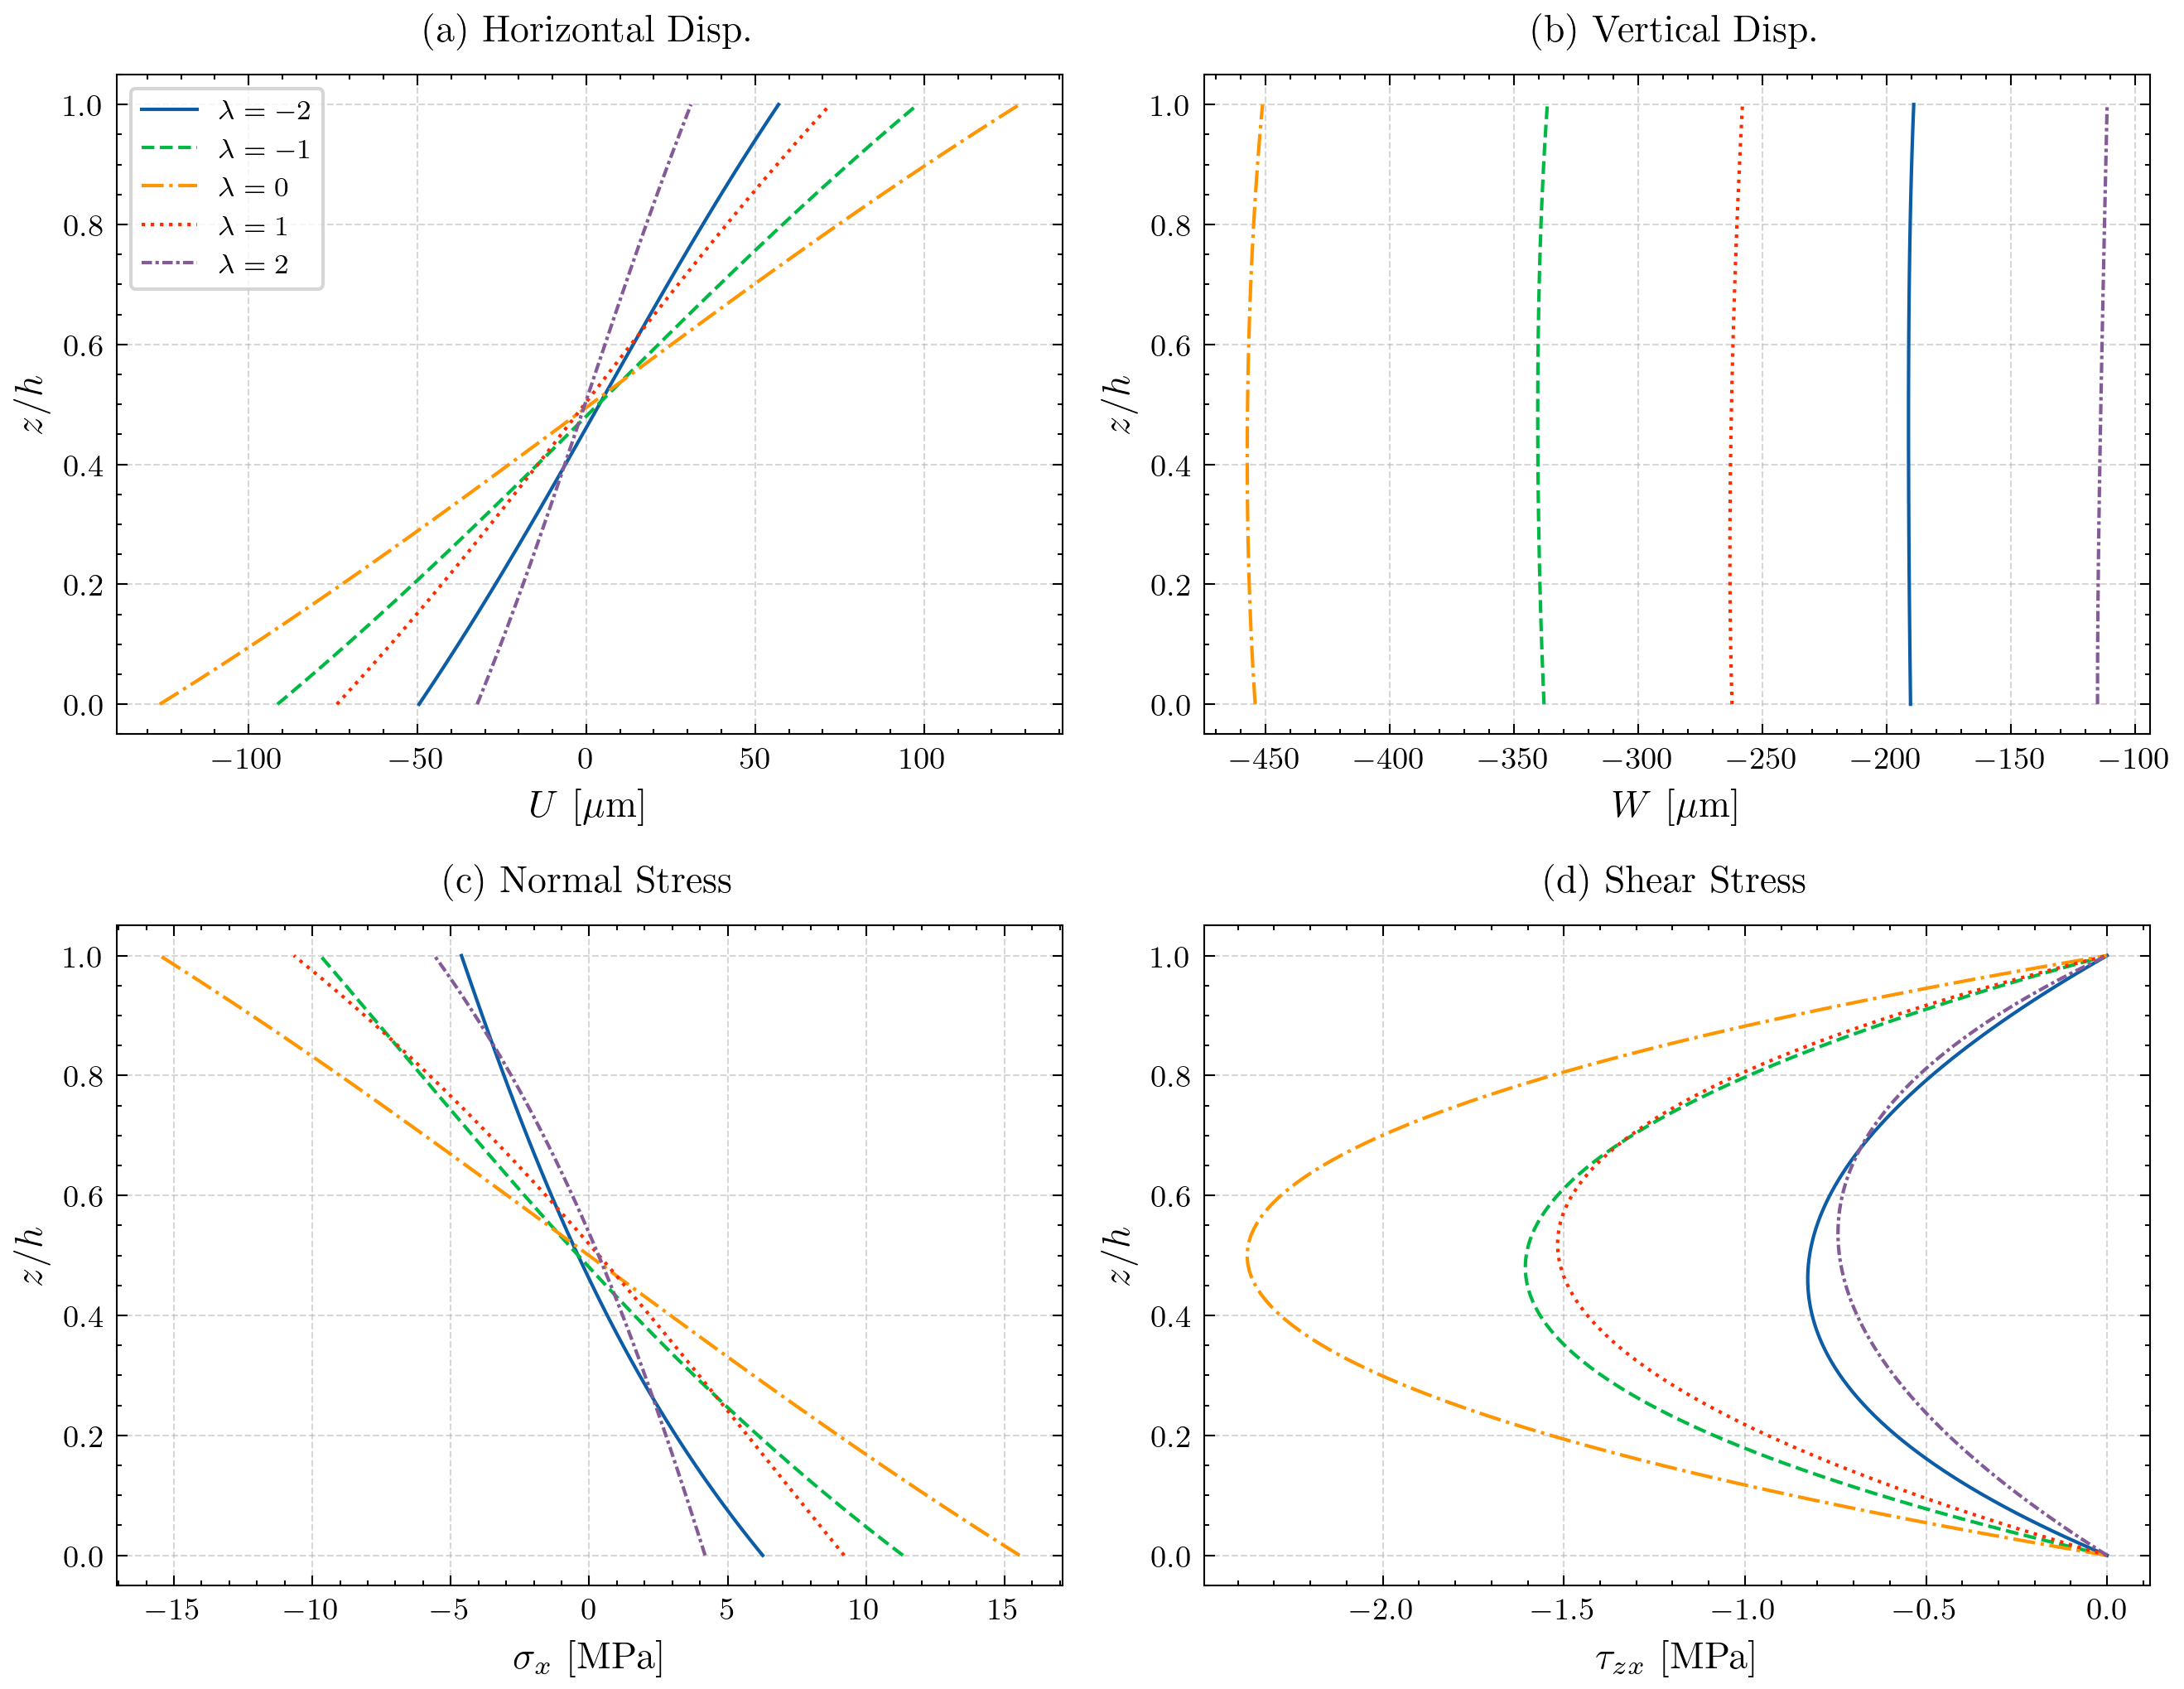

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve
import scienceplots
plt.style.use(['science'])
# ==========================================
# 1. 参数定义 (Parameters)
# ==========================================
# 几何参数
L = 1.0          # 梁长 (m)
h = 0.2          # 梁高 (m)
xi = np.pi / L   # xi = n * pi / l, n=1

# 材料常数 (GPa -> 转化为 MPa 以保持单位一致, 1 GPa = 1000 MPa)
# 题目中荷载是 MPa，所以刚度也用 MPa 计算，结果应力直接为 MPa
c11_0 = 41.3 * 1000
c13_0 = 10.1 * 1000
c33_0 = 36.2 * 1000
c55_0 = 10.0 * 1000

# 荷载幅值 (z=0处)
# p_z^0(x) = sin(pi*x/l) MPa. Amplitude = 1 MPa.
load_amp = 1.0 

# 梯度指数列表
lambdas = [-2, -1, 0, 1, 2]

# Z轴网格用于绘图
z_eval = np.linspace(0, h, 100)

# ==========================================
# 2. 求解核心函数 (Solver Core)
# ==========================================
def solve_beam(lam):
    """
    求解特定 lambda 下的系数和分布
    """
    # --- Step 1: 构建特征方程系数 ---
    # 这是一个关于 alpha 的4次多项式: A*alpha^4 + B*alpha^3 + C*alpha^2 + D*alpha + E = 0
    # 推导行列式 |M| = 0:
    # M11 = c55*a^2 + lam*c55*a - xi^2*c11
    # M12 = xi*(c13+c55)*a + lam*xi*c55
    # M21 = -xi*(c13+c55)*a - lam*xi*c13
    # M22 = c33*a^2 + lam*c33*a - xi^2*c55
    # Det = M11*M22 - M12*M21 = 0
    
    # 系数展开 (手动多项式乘法):
    # a^4 项: c55 * c33
    coeff_4 = c55_0 * c33_0
    
    # a^3 项: c55*lam*c33 + lam*c55*c33 = 2*lam*c55*c33
    coeff_3 = 2 * lam * c55_0 * c33_0
    
    # a^2 项: 
    # M11部分: c55 * (-xi^2*c55) + (-xi^2*c11)*c33 + (lam*c55)*(lam*c33)
    # M12*M21部分 (减去): - [ (xi*(c13+c55)) * (-xi*(c13+c55)) ] = + xi^2*(c13+c55)^2
    coeff_2 = (c55_0 * (-xi**2 * c55_0) + 
               (-xi**2 * c11_0) * c33_0 + 
               (lam * c55_0) * (lam * c33_0) + 
               (xi * (c13_0 + c55_0))**2)
               
    # a^1 项:
    # M11*M22: (lam*c55)*(-xi^2*c55) + (-xi^2*c11)*(lam*c33)
    # M12*M21: - [ (xi*(c13+c55)) * (-lam*xi*c13) + (lam*xi*c55) * (-xi*(c13+c55)) ]
    term1 = (lam * c55_0) * (-xi**2 * c55_0) + (-xi**2 * c11_0) * (lam * c33_0)
    term2 = - ( (xi*(c13_0+c55_0)) * (-lam*xi*c13_0) + (lam*xi*c55_0) * (-xi*(c13_0+c55_0)) )
    coeff_1 = term1 - term2
    
    # Constant 项 (a^0):
    # (-xi^2*c11) * (-xi^2*c55) - (lam*xi*c55) * (-lam*xi*c13)
    coeff_0 = (-xi**2 * c11_0) * (-xi**2 * c55_0) - (lam * xi * c55_0) * (-lam * xi * c13_0)
    
    # --- Step 2: 求解特征根 alpha ---
    coeffs = [coeff_4, coeff_3, coeff_2, coeff_1, coeff_0]
    alphas = np.roots(coeffs)
    
    # --- Step 3: 计算模态比 r_i = W0 / U0 ---
    # r_i = - M11 / M12
    # M11 = c55*a^2 + lam*c55*a - xi^2*c11
    # M12 = xi*(c13+c55)*a + lam*xi*c55
    r_vals = []
    for a in alphas:
        m11 = c55_0 * a**2 + lam * c55_0 * a - xi**2 * c11_0
        m12 = xi * (c13_0 + c55_0) * a + lam * xi * c55_0
        r_vals.append(-m11 / m12)
    r_vals = np.array(r_vals)
    
    # --- Step 4: 构建边界条件矩阵求解常数 C_i ---
    # 待求向量 X = [C1, C2, C3, C4]
    # Matrix A * X = B
    
    A_mat = np.zeros((4, 4), dtype=complex)
    B_vec = np.zeros(4, dtype=complex)
    
    # BC 1: tau_zx(0) = 0  => Sum C_i * (alpha_i + xi * r_i) = 0
    # BC 2: sigma_z(0) = load_amp => Sum C_i * (c33*r_i*alpha_i - c13*xi) = load_amp (注意 z=0 时 e^0=1)
    # BC 3: tau_zx(h) = 0  => Sum C_i * e^(alpha_i*h) * (alpha_i + xi * r_i) = 0
    # BC 4: sigma_z(h) = 0 => Sum C_i * e^(alpha_i*h) * e^(lam*h) * (c33*r_i*alpha_i - c13*xi) = 0
    
    for i in range(4):
        a = alphas[i]
        r = r_vals[i]
        
        # Tau term factor
        tau_fac = (a + xi * r)
        # Sigma term factor (pre-exponential part)
        sig_fac = (c33_0 * r * a - c13_0 * xi)
        
        A_mat[0, i] = tau_fac
        A_mat[1, i] = sig_fac
        A_mat[2, i] = tau_fac * np.exp(a * h)
        A_mat[3, i] = sig_fac * np.exp((a + lam) * h)
        
    B_vec[1] = load_amp
    
    # Solve
    C_coeffs = solve(A_mat, B_vec)
    
    # --- Step 5: 计算沿厚度 z 的分布 ---
    # 需要计算 U(z), W(z), Sigma_x(z), Tau_zx(z)
    # 注意：这里计算的是幅度函数 (Amplitude functions of z)
    # 实际场 u = U(z)cos(xi x), w = W(z)sin(xi x)
    # sigma_x = [c11*(-xi*U) + c13*W'] * e^lam*z * sin(xi x) (PPT中sigma_x应该是sin分布)
    
    U_z = np.zeros_like(z_eval, dtype=complex)
    W_z = np.zeros_like(z_eval, dtype=complex)
    SigX_z = np.zeros_like(z_eval, dtype=complex)
    Tau_z = np.zeros_like(z_eval, dtype=complex)
    
    for k, z in enumerate(z_eval):
        u_val = 0
        w_val = 0
        u_prime_val = 0
        w_prime_val = 0
        
        for i in range(4):
            # C * e^(alpha * z)
            term = C_coeffs[i] * np.exp(alphas[i] * z)
            u_val += term
            w_val += r_vals[i] * term
            u_prime_val += alphas[i] * term
            w_prime_val += r_vals[i] * alphas[i] * term
            
        U_z[k] = u_val
        W_z[k] = w_val
        
        # Constitutive laws (Amplitudes)
        # Sigma_x amplitude (coefficient of sin(xi*x)):
        # sigma_x = c11 * du/dx + c13 * dw/dz
        # du/dx = -xi * U * sin(xi x)
        # dw/dz = W' * sin(xi x)
        # So Amp = (c11 * (-xi * U) + c13 * W') * e^(lam*z)
        factor = np.exp(lam * z)
        SigX_z[k] = factor * (c11_0 * (-xi * u_val) + c13_0 * w_prime_val)
        
        # Tau_zx amplitude (coefficient of cos(xi*x)):
        # tau = c55 * (du/dz + dw/dx)
        # du/dz = U' * cos
        # dw/dx = xi * W * cos
        # Amp = c55 * (U' + xi*W) * e^(lam*z)
        Tau_z[k] = factor * c55_0 * (u_prime_val + xi * w_val)
        
    return U_z.real, W_z.real, SigX_z.real, Tau_z.real

# ==========================================
# 3. 绘图配置 (2*2 Subplots for Journal)
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "mathtext.fontset": "stix",
    "figure.dpi": 300
})

fig, axs = plt.subplots(2, 2, figsize=(9, 7)) # 调整大小适合期刊
axes = axs.flatten()
sub_titles = ['(a) Horizontal Disp.', '(b) Vertical Disp.', 
              '(c) Normal Stress', '(d) Shear Stress']
x_labels = ['$U$ [$\mu$m]', '$W$ [$\mu$m]', '$\sigma_x$ [MPa]', r'$\tau_{zx}$ [MPa]']
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

for idx, lam in enumerate(lambdas):
    U, W, Sx, Tzx = solve_beam(lam)
    z_n = z_eval / h
    # 计算位移时转为微米便于观察
    axes[0].plot(U * 1e6, z_n, label=rf'$\lambda={lam}$', linestyle=line_styles[idx])
    axes[1].plot(W * 1e6, z_n, label=rf'$\lambda={lam}$', linestyle=line_styles[idx])
    axes[2].plot(Sx, z_n, label=rf'$\lambda={lam}$', linestyle=line_styles[idx])
    axes[3].plot(Tzx, z_n, label=rf'$\lambda={lam}$', linestyle=line_styles[idx])

for i, ax in enumerate(axes):
    ax.set_title(sub_titles[i], loc='center', pad=10, fontsize=11, fontweight='bold')
    ax.set_xlabel(x_labels[i])
    ax.set_ylabel('$z/h$')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(direction='in', top=True, right=True)
    if i == 0:
        ax.legend(frameon=True, loc='best', fontsize=8)

plt.tight_layout()
# 建议保存为 pdf（矢量）或 tiff（高精位图）
# plt.savefig('FGM_Beam_Analysis.pdf', bbox_inches='tight')
plt.show()